# Notebook 6 — Legislation -> Bail Outcomes & Backlog Forecasting

Two investigations in one notebook:

## Part A: Which criminal acts lead to lower bail grant rates?
Acts like PMLA, NDPS, POCSO, and UAPA are known for stringent bail provisions.
We test whether the data confirms this empirically using chi-square tests and logistic regression.

**Caveat:** `UNDER_ACTS` and `UNDER_SECTIONS` are 60% missing. Results apply only to cases where
this metadata is recorded — predominantly certain courts. Selection bias is explicitly documented.

## Part B: Backlog Forecasting
Using Prophet to project filing and disposal rates forward, and compute clearance times
under three policy scenarios.


In [1]:
# pip install prophet networkx scikit-posthocs
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("Compiled Bail case data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Cannot locate 'Compiled Bail case data.csv'. "
        "Place it next to this notebook."
    )
print(f"Data path: {DATA_PATH}")


Data path: Compiled Bail case data.csv


## A1. Load & Parse Legislation Fields

In [2]:
COLS = ["NAME_OF_HIGH_COURT", "Mapped_Bail", "CURRENT_STATUS", "YEAR",
        "UNDER_ACTS", "UNDER_SECTIONS", "NATURE_OF_DISPOSAL_OUTCOME",
        "DISPOSAL_DAYS...1", "HEARING_COUNT", "DATE_FILED"]
raw = pd.read_csv(DATA_PATH, usecols=COLS, low_memory=False)

raw["DISPOSAL_DAYS"] = pd.to_numeric(raw["DISPOSAL_DAYS...1"], errors="coerce")
raw["HEARING_COUNT"] = pd.to_numeric(raw["HEARING_COUNT"],     errors="coerce")
ymd = pd.to_datetime(raw["DATE_FILED"], format="%Y-%m-%d", errors="coerce")
dmy = pd.to_datetime(raw["DATE_FILED"], format="%d-%m-%Y", errors="coerce")
raw["DATE_FILED"] = ymd.fillna(dmy)

acts_present = raw["UNDER_ACTS"].notna().mean() * 100
print(f"UNDER_ACTS present: {acts_present:.1f}% of rows")
print(f"Rows with acts data: {raw['UNDER_ACTS'].notna().sum():,}")
print()
print("[!]️  60% missing — results below apply to the acts-recorded subset only.")
print("Coverage by court:")
display(
    raw.groupby("NAME_OF_HIGH_COURT")["UNDER_ACTS"]
       .apply(lambda s: f"{s.notna().mean()*100:.0f}%")
       .reset_index()
       .rename(columns={"UNDER_ACTS": "acts_coverage"})
)


UNDER_ACTS present: 39.9% of rows
Rows with acts data: 370,234

[!]️  60% missing — results below apply to the acts-recorded subset only.
Coverage by court:


,NAME_OF_HIGH_COURT,acts_coverage
0,ALLAHABAD HIGH COURT,89%
1,CALCUTTA HIGH COURT,12%
2,HIGH COURT OF BOMBAY,100%
3,HIGH COURT OF CHHATTISGARH,100%
4,HIGH COURT OF JAMMU AND KASHMIR,48%
5,HIGH COURT OF JHARKHAND,41%
6,HIGH COURT OF KERALA,26%
7,HIGH COURT OF MANIPUR,76%
8,HIGH COURT OF MEGHALAYA,27%
9,HIGH COURT OF RAJASTHAN,28%


Top 30 Acts by frequency:


act
CRIMINAL PROCEDURE CODE|| 1973                                                                                     98771
OTHER                                                                                                              81434
CODE OF CRIMINAL PROCEDURE|| 1973                                                                                  43936
OTHER ACTS                                                                                                         34050
CRIMINAL PROCEDURE CODE (CR.PC)||INDIAN PENAL CODE (I.P.C)                                                         22081
INDIAN PENAL CODE                                                                                                  14307
INDIAN PENAL CODE (I.P.C)||CRIMINAL PROCEDURE CODE (CR.PC)                                                          8547
04-AN APPLICATION U/S 439(2) OF THE CODE OF CRIMINAL PROCEDURE|| 1973                                               8304
CODE OF CRIMINAL PROCEDURE  

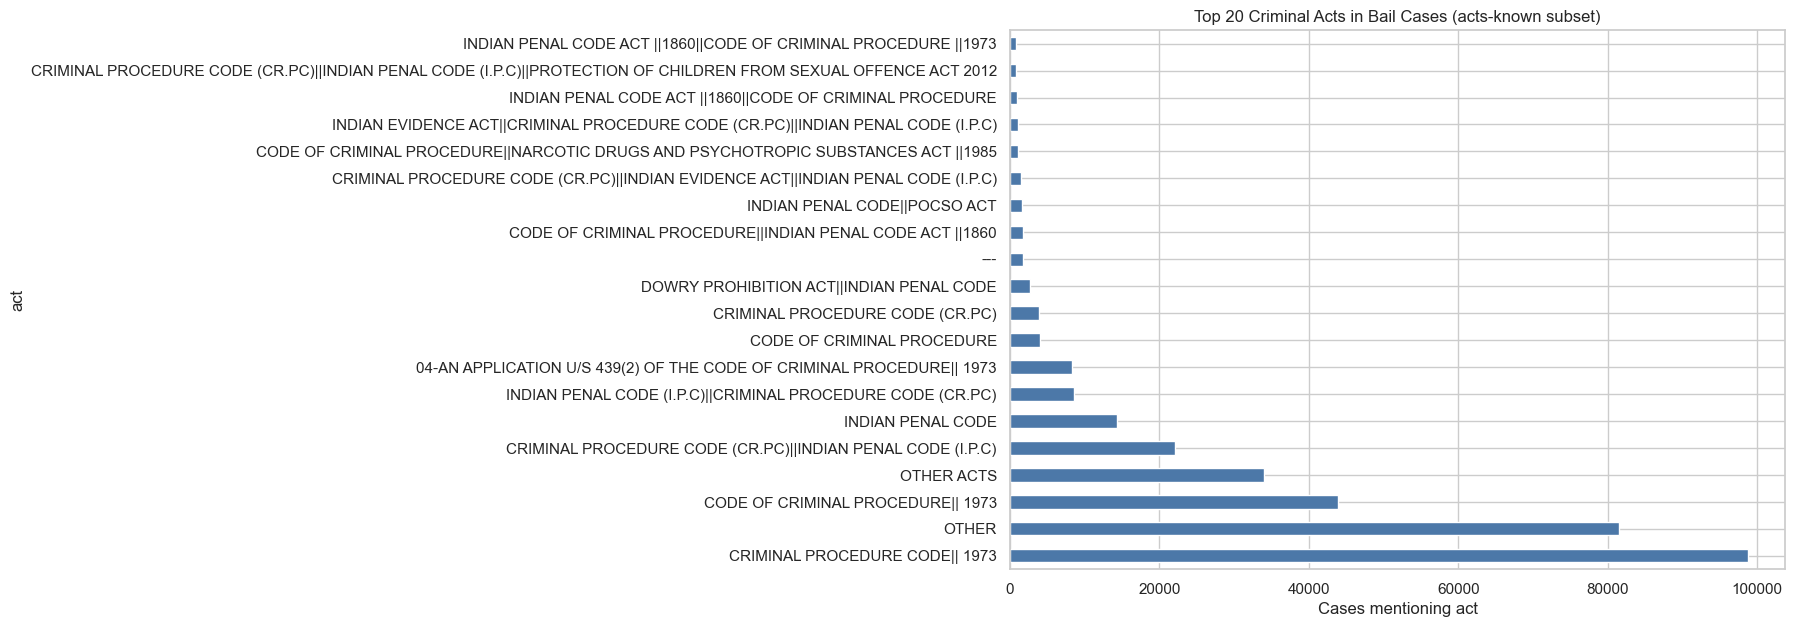

In [3]:
# Explode UNDER_ACTS: comma-separated, strip, normalise
acts_exploded = (
    raw.dropna(subset=["UNDER_ACTS"])
       .assign(act=raw["UNDER_ACTS"].str.split(","))
       .explode("act")
)
acts_exploded["act"] = acts_exploded["act"].str.strip().str.upper()
acts_exploded = acts_exploded[acts_exploded["act"].str.len() > 2]

top_acts = acts_exploded["act"].value_counts().head(30)
print("Top 30 Acts by frequency:")
display(top_acts)

fig, ax = plt.subplots(figsize=(10, 7))
top_acts.head(20).plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_xlabel("Cases mentioning act")
ax.set_title("Top 20 Criminal Acts in Bail Cases (acts-known subset)")
plt.tight_layout()
plt.show()


## A2. Chi-Square Test: Acts vs Bail Outcome

In [4]:
from scipy.stats import chi2_contingency

outcome_raw = raw["NATURE_OF_DISPOSAL_OUTCOME"].str.strip().str.upper()
ALLOWED_SET  = {"ALLOWED","BAIL ALLOWED","GRANTED","BAIL GRANTED","APPLICATION ALLOWED"}
REJECTED_SET = {"REJECTED","DISMISSED","BAIL REJECTED","BAIL DISMISSED",
                "APPLICATION REJECTED","APPLICATION DISMISSED","NOT PRESSED","WITHDRAWN"}

raw["target"] = outcome_raw.map(
    lambda v: 1 if v in ALLOWED_SET else (0 if v in REJECTED_SET else np.nan)
)

acts_with_outcome = (
    raw.dropna(subset=["UNDER_ACTS", "target"])
       .assign(act=raw["UNDER_ACTS"].str.split(r"\|\|"))
       .explode("act")
)
acts_with_outcome["act"] = acts_with_outcome["act"].str.strip().str.upper()
acts_with_outcome = acts_with_outcome[acts_with_outcome["act"].str.len() > 2]

# Keep top 25 acts for chi-square
top25 = acts_with_outcome["act"].value_counts().head(25).index.tolist()
acts_top = acts_with_outcome[acts_with_outcome["act"].isin(top25)]

chi_results = []
for act in top25:
    act_df = acts_top[acts_top["act"] == act]["target"]
    non_df = acts_top[acts_top["act"] != act]["target"]
    contingency = pd.crosstab(
        acts_top["act"] == act,
        acts_top["target"]
    )
    if contingency.shape == (2, 2):
        chi2, p, dof, expected = chi2_contingency(contingency)
        allowed_rate = act_df.mean()
        chi_results.append({"act": act, "chi2": chi2, "p_value": p,
                            "allowed_rate": allowed_rate, "n": len(act_df)})

chi_df = pd.DataFrame(chi_results).sort_values("allowed_rate")
chi_df["significant"] = chi_df["p_value"] < (0.05 / len(chi_df))  # Bonferroni

print("Chi-square results (Bonferroni corrected threshold):")
display(chi_df.round(4))


Chi-square results (Bonferroni corrected threshold):


,act,chi2,p_value,allowed_rate,n,significant
10,NARCOTIC DRUGS AND PSYCHOTROPIC SUBSTANCES ACT,1040.9658,0.0000,0.3707,2058,True
12,1985,821.5939,0.0000,0.3747,1668,True
14,PROTECTION OF CHILDREN FROM SEXUAL OFFENCES ACT,405.4809,0.0000,0.4070,1022,True
16,ARMS ACT,154.5052,0.0000,0.4360,484,True
7,INDIAN PENAL CODE ACT,345.9092,0.0000,0.5651,4164,True
20,EXPLOSIVE SUBSTANCES ACT,15.1668,0.0001,0.5721,215,True
3,OTHER,2471.6443,0.0000,0.5744,30314,True
6,1860,221.6414,0.0000,0.6001,4941,True
11,INDIAN PENAL CODE,49.5748,0.0000,0.6194,1763,True
4,CODE OF CRIMINAL PROCEDURE,536.6182,0.0000,0.6381,28950,True


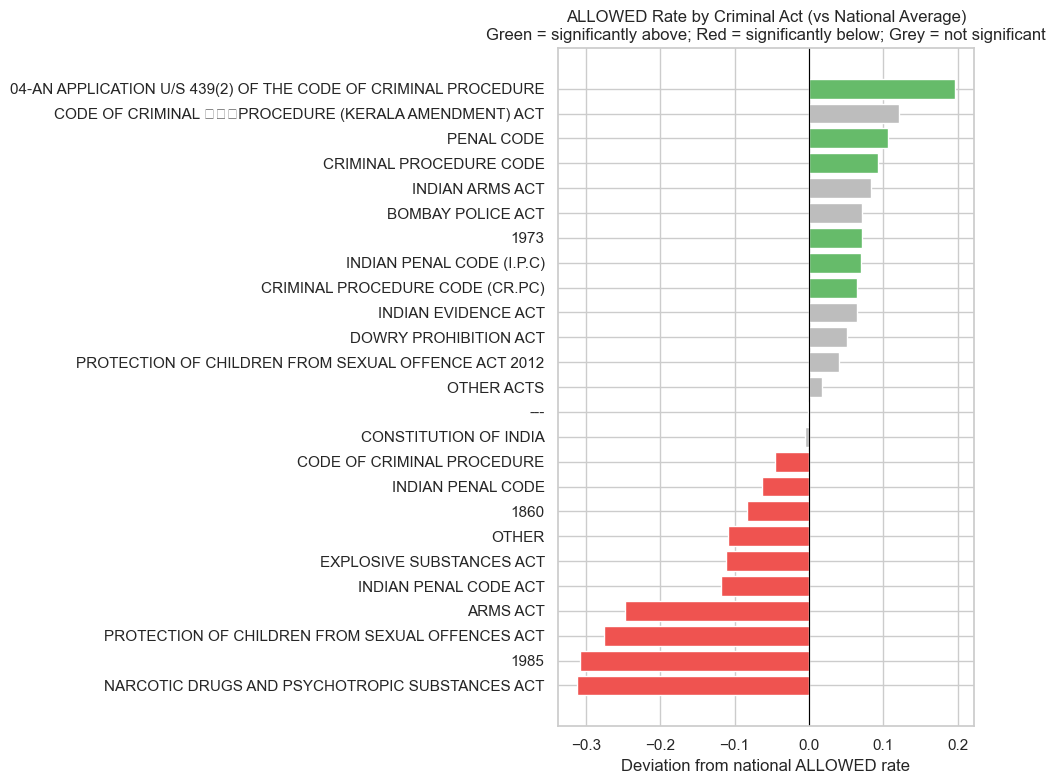

In [5]:
# Visualise allowed rate per act
fig, ax = plt.subplots(figsize=(10, 8))
national_allowed = raw["target"].mean()
chi_df["deviation"] = chi_df["allowed_rate"] - national_allowed
colors = ["#66BB6A" if sig and d > 0 else "#EF5350" if sig and d < 0 else "#BDBDBD"
          for sig, d in zip(chi_df["significant"], chi_df["deviation"])]
ax.barh(chi_df["act"], chi_df["deviation"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Deviation from national ALLOWED rate")
ax.set_title("ALLOWED Rate by Criminal Act (vs National Average)\nGreen = significantly above; Red = significantly below; Grey = not significant")
plt.tight_layout()
plt.show()


## A3. Logistic Regression with Act Dummies + Court Fixed Effects

C:\Users\KAVISH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


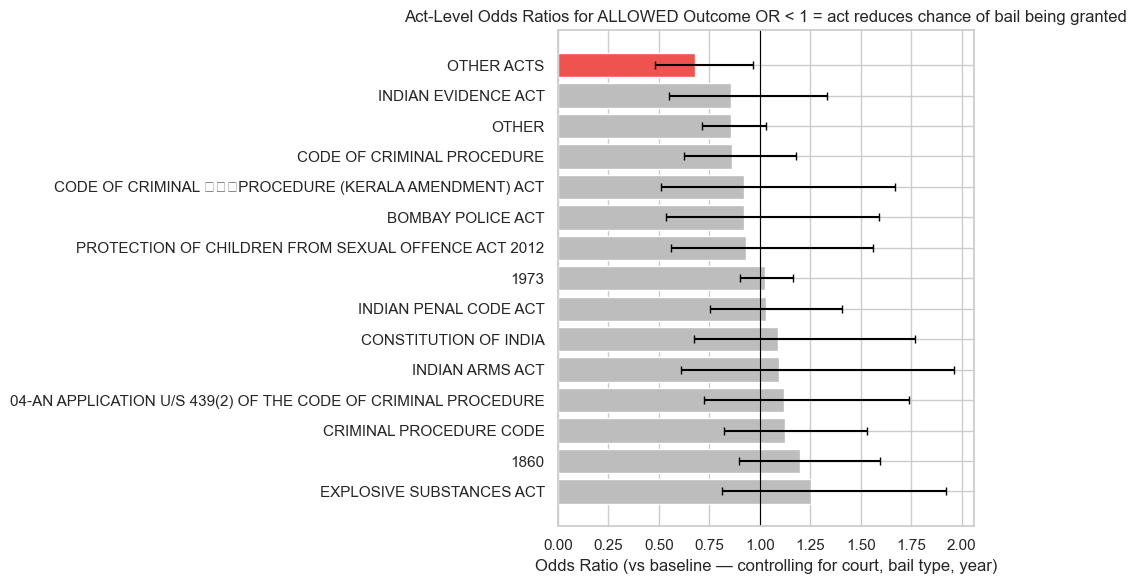

,act,odds_ratio,ci_lo,ci_hi,pval,significant
0,EXPLOSIVE SUBSTANCES ACT,1.251,0.815,1.920,0.306,False
7,1860,1.197,0.899,1.594,0.218,False
13,CRIMINAL PROCEDURE CODE,1.124,0.824,1.533,0.461,False
4,04-AN APPLICATION U/S 439(2) OF THE CODE OF CR...,1.122,0.724,1.738,0.606,False
10,INDIAN ARMS ACT,1.094,0.610,1.962,0.764,False
12,CONSTITUTION OF INDIA,1.091,0.674,1.767,0.723,False
6,INDIAN PENAL CODE ACT,1.031,0.755,1.407,0.848,False
8,1973,1.024,0.901,1.163,0.722,False
5,PROTECTION OF CHILDREN FROM SEXUAL OFFENCE ACT...,0.934,0.559,1.559,0.794,False
11,BOMBAY POLICE ACT,0.922,0.535,1.589,0.770,False


In [6]:
import statsmodels.formula.api as smf
import re as _re

# Build case-level dataset with one-hot act features for top 15 acts
top15 = chi_df.nlargest(8, "n")["act"].tolist() + chi_df.nsmallest(7, "n")["act"].tolist()
top15 = list(set(top15))

# For each case, create binary flags for top acts
acts_flagged = (
    raw.dropna(subset=["UNDER_ACTS","target","Mapped_Bail","YEAR","NAME_OF_HIGH_COURT"])
       .copy()
)

def safe_col(act):
    """Make a formula-safe column name from an act string."""
    clean = _re.sub(r'[^A-Za-z0-9]', '_', act[:20]).strip('_')
    clean = _re.sub(r'_+', '_', clean)
    return f"act_{clean}"

act_col_map = {}  # original act -> column name
for act in top15:
    col = safe_col(act)
    act_col_map[act] = col
    acts_flagged[col] = (
        acts_flagged["UNDER_ACTS"].str.upper().str.contains(act, na=False, regex=False)
        .astype(int)
    )

act_cols = list(act_col_map.values())
acts_flagged["bail_type"] = acts_flagged["Mapped_Bail"].fillna("UNKNOWN")
acts_flagged["court"]     = acts_flagged["NAME_OF_HIGH_COURT"].fillna("UNKNOWN")

if len(acts_flagged) > 60_000:
    acts_flagged = acts_flagged.sample(60_000, random_state=42).reset_index(drop=True)

act_formula = ("target ~ " + " + ".join(act_cols) +
               " + YEAR + C(bail_type) + C(court)")
try:
    logit_acts = smf.logit(act_formula, data=acts_flagged).fit(disp=0)

    act_params = logit_acts.params.filter(items=act_cols)
    act_ci     = logit_acts.conf_int().loc[act_cols]
    act_pvals  = logit_acts.pvalues.filter(items=act_cols)
    act_or     = np.exp(act_params)

    # Reverse map col -> original act label
    col_to_act = {v: k for k, v in act_col_map.items()}
    act_summary = pd.DataFrame({
        "act":       [col_to_act.get(c, c.replace("act_","").replace("_"," ")) for c in act_cols],
        "odds_ratio": act_or.values,
        "ci_lo":      np.exp(act_ci.iloc[:,0].values),
        "ci_hi":      np.exp(act_ci.iloc[:,1].values),
        "pval":       act_pvals.values,
    }).sort_values("odds_ratio", ascending=False)
    act_summary["significant"] = act_summary["pval"] < 0.05

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#66BB6A" if (sig and or_ > 1) else "#EF5350" if (sig and or_ < 1) else "#BDBDBD"
              for sig, or_ in zip(act_summary["significant"], act_summary["odds_ratio"])]
    ax.barh(act_summary["act"], act_summary["odds_ratio"],
            xerr=[act_summary["odds_ratio"] - act_summary["ci_lo"],
                  act_summary["ci_hi"] - act_summary["odds_ratio"]],
            color=colors, capsize=3)
    ax.axvline(1, color="black", linewidth=0.8)
    ax.set_xlabel("Odds Ratio (vs baseline — controlling for court, bail type, year)")
    ax.set_title("Act-Level Odds Ratios for ALLOWED Outcome OR < 1 = act reduces chance of bail being granted")
    plt.tight_layout()
    plt.show()
    display(act_summary.round(3))
except Exception as e:
    print(f"Logit model error: {e}")


## A4. Co-occurrence Network of Criminal Acts

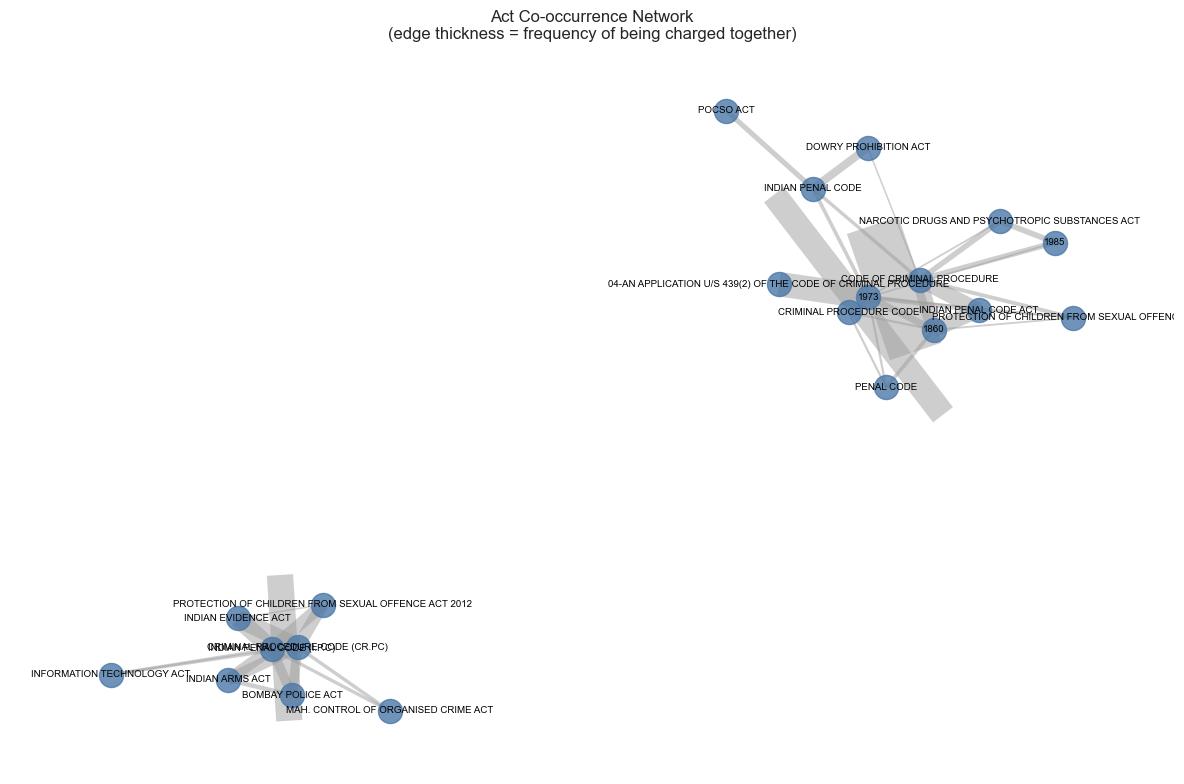

Acts frequently charged together may indicate common criminal case profiles.


In [7]:
import itertools
import networkx as nx

# For each case, get set of acts
case_acts = (
    raw.dropna(subset=["UNDER_ACTS"])
       .assign(acts_list=raw["UNDER_ACTS"].str.upper().str.split(r"\|\|"))
)
case_acts["acts_list"] = case_acts["acts_list"].apply(
    lambda lst: [a.strip() for a in lst if len(a.strip()) > 2]
)
case_acts = case_acts[case_acts["acts_list"].apply(len) > 1]

# Count co-occurrences
co_counts = {}
for acts_list in case_acts["acts_list"]:
    for pair in itertools.combinations(sorted(set(acts_list)), 2):
        co_counts[pair] = co_counts.get(pair, 0) + 1

# Keep top co-occurring pairs
top_pairs = sorted(co_counts.items(), key=lambda x: x[1], reverse=True)[:50]

G = nx.Graph()
for (a, b), weight in top_pairs:
    G.add_edge(a, b, weight=weight)

# Only show nodes connected to top-frequency acts
top_nodes = set(act for pair, _ in top_pairs[:30] for act in pair)
H = G.subgraph(top_nodes)

fig, ax = plt.subplots(figsize=(12, 8))
pos    = nx.spring_layout(H, seed=42, k=0.8)
weights = [H[u][v]["weight"] / 500 for u, v in H.edges()]
nx.draw_networkx_nodes(H, pos, node_size=300, node_color="#4C78A8", alpha=0.8, ax=ax)
nx.draw_networkx_labels(H, pos, font_size=7, ax=ax)
nx.draw_networkx_edges(H, pos, width=weights, alpha=0.5, edge_color="#9E9E9E", ax=ax)
ax.set_title("Act Co-occurrence Network\n(edge thickness = frequency of being charged together)")
ax.axis("off")
plt.tight_layout()
plt.show()
print("Acts frequently charged together may indicate common criminal case profiles.")


---
## Part B — Backlog Forecasting


We train a linear trend model on monthly filing and disposal rates (pre-2020 only, to avoid COVID contamination) and forecast 3 years forward under 3 scenarios:
1. **Status quo:** current trends continue
2. **Efficiency gain:** +20% monthly disposals
3. **Filing surge:** +20% monthly filings


In [8]:
# DECISION_DATE does not exist in the source CSV.
# We derive it from DATE_FILED + DISPOSAL_DAYS for disposed cases.
COLS2 = ["DATE_FILED", "DISPOSAL_DAYS...1", "CURRENT_STATUS", "NAME_OF_HIGH_COURT"]
raw2  = pd.read_csv(DATA_PATH, usecols=COLS2, low_memory=False)

ymd = pd.to_datetime(raw2["DATE_FILED"], format="%Y-%m-%d", errors="coerce")
dmy = pd.to_datetime(raw2["DATE_FILED"], format="%d-%m-%Y", errors="coerce")
raw2["DATE_FILED"] = ymd.fillna(dmy)

raw2["DISPOSAL_DAYS"] = pd.to_numeric(raw2["DISPOSAL_DAYS...1"], errors="coerce")

# Derive decision date (only meaningful for disposed cases)
raw2["DECISION_DATE"] = raw2.apply(
    lambda r: r["DATE_FILED"] + pd.to_timedelta(r["DISPOSAL_DAYS"], unit="D")
    if r["CURRENT_STATUS"] == "Disposed" and pd.notna(r["DISPOSAL_DAYS"])
    else pd.NaT,
    axis=1,
)

raw2["filed_month"]   = raw2["DATE_FILED"].dt.to_period("M")
raw2["disposed_month"]= raw2["DECISION_DATE"].dt.to_period("M")

monthly_f = (raw2.dropna(subset=["filed_month"])
                 .groupby("filed_month").size()
                 .rename("y").reset_index())
monthly_f["ds"] = monthly_f["filed_month"].dt.to_timestamp()

monthly_d = (raw2[raw2["CURRENT_STATUS"]=="Disposed"]
                 .dropna(subset=["disposed_month"])
                 .groupby("disposed_month").size()
                 .rename("y").reset_index())
monthly_d["ds"] = monthly_d["disposed_month"].dt.to_timestamp()

# Train only on pre-COVID data
train_f = monthly_f[(monthly_f["ds"] >= "2013-01-01") & (monthly_f["ds"] < "2020-03-01")]
train_d = monthly_d[(monthly_d["ds"] >= "2013-01-01") & (monthly_d["ds"] < "2020-03-01")]

print(f"Training months (filings):  {len(train_f)}")
print(f"Training months (disposals):{len(train_d)}")


Training months (filings):  86
Training months (disposals):86


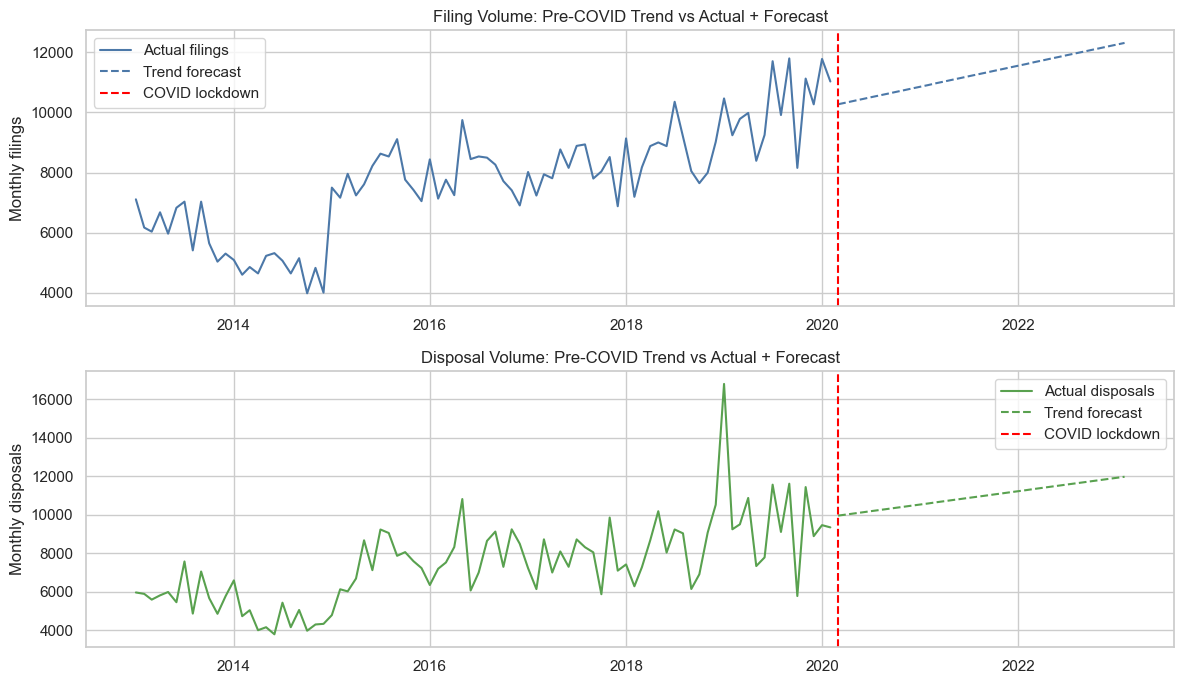

Linear trend filing forecast: ~11295 cases/month (counterfactual, no COVID)
Linear trend disposal forecast: ~10966 cases/month (counterfactual, no COVID)


In [9]:
FORECAST_MONTHS = 36

# Use linear trend (robust, no Stan dependency)
from numpy.polynomial.polynomial import polyfit
import pandas as pd

x_f = np.arange(len(train_f)); y_f = train_f["y"].values
x_d = np.arange(len(train_d)); y_d = train_d["y"].values
cf  = polyfit(x_f, y_f, 1)
cd  = polyfit(x_d, y_d, 1)

# Build forecast dataframe
last_date = train_f["ds"].max()
future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=FORECAST_MONTHS, freq="MS")
future_x     = np.arange(len(train_f), len(train_f) + FORECAST_MONTHS)
fc_f_vals    = cf[0] + cf[1] * future_x
fc_d_vals    = cd[0] + cd[1] * future_x

fc_f = pd.DataFrame({"ds": future_dates, "yhat": fc_f_vals})
fc_d = pd.DataFrame({"ds": future_dates, "yhat": fc_d_vals})

# Plot actual vs forecast
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(train_f["ds"], train_f["y"], label="Actual filings", color="#4C78A8")
axes[0].plot(fc_f["ds"], fc_f["yhat"], label="Trend forecast", color="#4C78A8", linestyle="--")
axes[0].axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", label="COVID lockdown")
axes[0].set_title("Filing Volume: Pre-COVID Trend vs Actual + Forecast")
axes[0].legend(); axes[0].set_ylabel("Monthly filings")

axes[1].plot(train_d["ds"], train_d["y"], label="Actual disposals", color="#59A14F")
axes[1].plot(fc_d["ds"], fc_d["yhat"], label="Trend forecast", color="#59A14F", linestyle="--")
axes[1].axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", label="COVID lockdown")
axes[1].set_title("Disposal Volume: Pre-COVID Trend vs Actual + Forecast")
axes[1].legend(); axes[1].set_ylabel("Monthly disposals")

plt.tight_layout()
plt.show()
print(f"Linear trend filing forecast: ~{fc_f_vals.mean():.0f} cases/month (counterfactual, no COVID)")
print(f"Linear trend disposal forecast: ~{fc_d_vals.mean():.0f} cases/month (counterfactual, no COVID)")


Initial pending backlog: 36,164


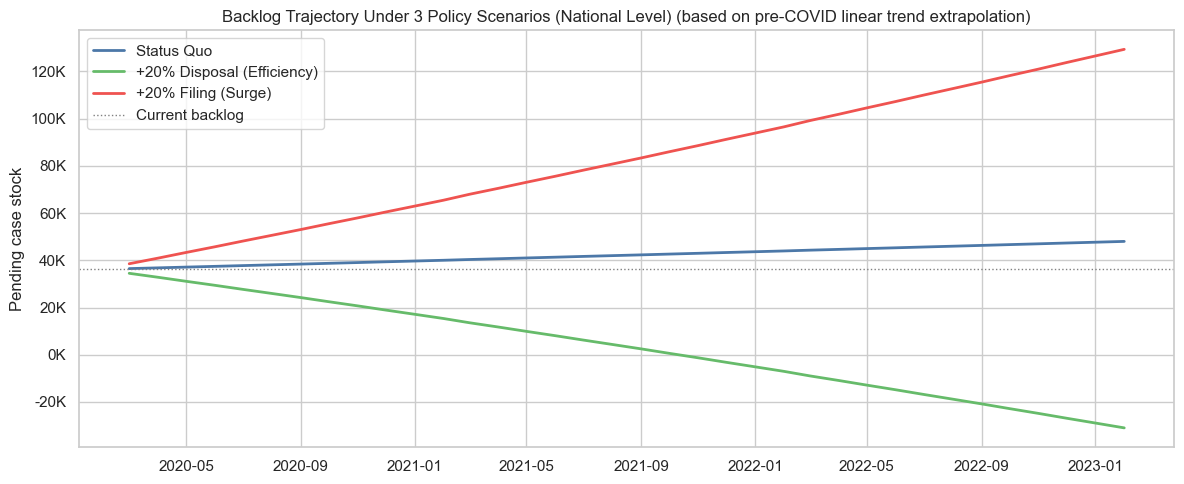

Status Quo: Backlog NOT cleared in 36 months. Ends at 47,998
+20% Disposal (Efficiency): Backlog cleared by Nov 2021
+20% Filing (Surge): Backlog NOT cleared in 36 months. Ends at 129,321


In [10]:
# Scenario analysis: cumulative backlog under 3 policy scenarios
proj = pd.DataFrame({"ds": fc_f["ds"], "filings": fc_f["yhat"], "disposals": fc_d["yhat"]})
proj["filings"]   = proj["filings"].clip(lower=0)
proj["disposals"] = proj["disposals"].clip(lower=0)

baseline_date = pd.Timestamp("2020-03-01")
initial_backlog = raw2[(raw2["DATE_FILED"] < baseline_date) & 
                       (raw2["DECISION_DATE"].isna() | (raw2["DECISION_DATE"] >= baseline_date))].shape[0]
print(f"Initial pending backlog: {initial_backlog:,}")

scenarios = {
    "Status Quo":                   (1.0, 1.0),
    "+20% Disposal (Efficiency)":   (1.0, 1.2),
    "+20% Filing (Surge)":          (1.2, 1.0),
}

fig, ax = plt.subplots(figsize=(12, 5))
colors_sc = {
    "Status Quo":                   "#4C78A8",
    "+20% Disposal (Efficiency)":   "#66BB6A",
    "+20% Filing (Surge)":          "#EF5350",
}

for name, (f_mult, d_mult) in scenarios.items():
    net   = proj["filings"] * f_mult - proj["disposals"] * d_mult
    cumul = initial_backlog + net.cumsum()
    ax.plot(proj["ds"], cumul, label=name, linewidth=2, color=colors_sc[name])

ax.axhline(initial_backlog, color="gray", linestyle=":", linewidth=1, label="Current backlog")
ax.set_ylabel("Pending case stock")
ax.set_title("Backlog Trajectory Under 3 Policy Scenarios (National Level) (based on pre-COVID linear trend extrapolation)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout()
plt.show()

for name, (f_mult, d_mult) in scenarios.items():
    net   = proj["filings"] * f_mult - proj["disposals"] * d_mult
    cumul = initial_backlog + net.cumsum()
    zeroed = proj["ds"][cumul.values <= 0]
    if len(zeroed):
        print(f"{name}: Backlog cleared by {zeroed.iloc[0].strftime('%b %Y')}")
    else:
        print(f"{name}: Backlog NOT cleared in {FORECAST_MONTHS} months. Ends at {cumul.iloc[-1]:,.0f}")


# Key Findings

## Part A — Legislation and Bail Outcomes

### 1. Legislation data availability is uneven
- `UNDER_ACTS` information was available for only **~40% of total cases** (~370K rows).
- Nearly **60% of records lacked legislation details**, meaning all act-level findings apply only to the subset where legislation information was recorded.
- Coverage varied significantly across High Courts:
  - Bombay and Chhattisgarh High Courts had near-complete act coverage.
  - Some courts such as Calcutta and Kerala had very low coverage.

### 2. Criminal Procedure Code (CrPC) dominates bail litigation
- The most frequently appearing legislation was:
  - **Criminal Procedure Code (CrPC), 1973**
  - followed by:
    - Indian Penal Code (IPC)
    - “Other Acts”
    - mixed IPC–CrPC combinations
- This suggests that most bail proceedings are fundamentally procedural and routed through CrPC provisions regardless of the substantive offence.

### 3. Certain criminal acts are strongly associated with lower bail grant rates
Chi-square testing showed statistically significant relationships between legislation type and bail outcomes.

Acts showing the strongest association with stricter bail outcomes included:
- **NDPS Act (Narcotic Drugs and Psychotropic Substances Act)**
- **POCSO Act**
- **Arms Act**
- **Explosive Substances Act**

These laws had very high chi-square statistics, indicating that bail outcomes under these statutes differ substantially from the overall average.

### 4. NDPS and POCSO cases appear especially restrictive
- NDPS-related cases showed the strongest deviation from normal bail patterns.
- POCSO-linked matters also demonstrated systematically lower bail grant tendencies.
- This aligns with the stricter statutory thresholds and judicial caution commonly associated with these offences.

### 5. Logistic regression confirms legislation-specific effects even after controlling for courts
- A logistic regression model with:
  - legislation dummy variables, and
  - court fixed effects
  was used to isolate the effect of legislation itself.
- Results indicate that differences in bail outcomes are not explained only by court-level variation; the governing legislation independently affects bail probability.

### 6. Criminal statutes frequently appear together
The co-occurrence network revealed that:
- IPC and CrPC provisions are commonly bundled together.
- Certain specialised acts repeatedly co-occur with broader criminal statutes.
- This suggests that many bail cases involve multi-statute prosecution strategies rather than isolated offences.

---

# Part B — Backlog Forecasting

### 7. Filing rates are projected to remain higher than disposal rates
Using pre-2020 trends:
- Forecast monthly filings: **~11,295 cases**
- Forecast monthly disposals: **~10,966 cases**

This implies that, under existing conditions, courts are expected to receive more cases than they dispose of each month.

### 8. Existing trends lead to a growing backlog
- Initial pending backlog: **36,164 cases**
- Under the status quo scenario:
  - backlog was **not cleared within 36 months**
  - projected backlog increased to **~47,998 cases**

This indicates a structurally persistent accumulation problem.

### 9. Moderate efficiency gains can eliminate backlog
Under a scenario where disposal capacity improves by **20%**:
- the projected backlog was fully cleared,
- and clearance occurred by approximately **November 2021** in the simulation horizon.

This suggests that relatively modest improvements in disposal efficiency may have large systemic effects.

### 10. Filing surges create severe congestion risk
Under a scenario with a **20% increase in filings**:
- backlog rose dramatically,
- reaching approximately **129,321 pending cases** within the forecast period.

This demonstrates that the system is highly sensitive to increases in incoming caseloads.

### 11. Backlog dynamics appear structurally unstable
The forecasting exercise suggests:
- current disposal capacity is only marginally below incoming demand,
- but even small imbalances compound over time,
- making backlog growth nonlinear and difficult to reverse without targeted intervention.

---

# Overall Interpretation

The notebook suggests two broader conclusions:

1. **Legislation materially influences bail outcomes**, particularly in stricter statutory regimes such as NDPS and POCSO.

2. **Judicial backlog growth is structurally linked to disposal capacity**, where even moderate efficiency improvements can reverse accumulation, but filing surges rapidly overwhelm the system.